In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# When the equilibrium constant is measured, not computed (Illustrations 13.1-5 and 13.1-7, Figure 13.1-1)

$$2\,\mathrm{H_2S}\;\rightleftharpoons\;2\,\mathrm{H_2}+\mathrm{S_2}
\qquad\qquad
\mathrm{CO_2}+\mathrm{H_2}\;\rightleftharpoons\;\mathrm{CO}+\mathrm{H_2O}$$

Most of Section 13.1 computes $K_a$ from Appendix A.IV and then solves for the composition.
These two illustrations run the other way: $K_a$ is **handed over as a measurement** --
$2.17\times10^{-5}$ and $0.693$ -- and the only work is the composition. That makes them
the right place to look at what the algebra does, because nothing is hiding in the
thermochemistry.

| | the measurement | what the algebra shows |
|---|---|---|
| **13.1-5** | $K_a=2.17\times10^{-5}$ at 700 $^{\circ}$C | **a cubic with a root that is not the answer.** $K_a$ is tiny, so the illustration linearizes -- and the notebook checks the approximation against the exact root instead of trusting it |
| **13.1-7** | $K_a=0.693$ at 1000 K | $\sum_i\nu_i=0$, so pressure enters **only** through $K_\nu$. From 1 bar to 500 atm the extent moves by 2 % |

**Figure 13.1-1** is 13.1-7's own reaction seen from the other side: the total Gibbs energy
against extent, with its minimum at the same $X$ the equilibrium relation gives. It is the
first figure in the chapter and it is the picture the whole chapter rests on.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from thermo.reaction import (Reaction, equilibrium_extent, K_nu_from_eos,
                             gibbs_curve, formation_gibbs_T, R)
from thermo.pr_mixture import PRMixture
from thermo.peng_robinson import PengRobinson
from thermo.charts import use_book_style
use_book_style()

shift = Reaction.parse("CO2 + H2 = CO + H2O(g)").check_balance()
print(f"  {shift.equation:28s} dnu = {shift.delta_nu:+g}")

# 2 H2S = 2 H2 + S2 is NOT built as a `Reaction`, and the reason is the illustration's
# own: Appendix A.IV has no S2 row. `Reaction.parse` validates every species against the
# appendix and would raise here -- which is exactly why the book hands over a MEASURED Ka
# for this reaction instead of asking the reader to compute one.
from thermo.data import get_reaction_species
for sp in ("H2S", "H2", "S2"):
    try:
        get_reaction_species(sp); print(f"  Appendix A.IV has   {sp}")
    except KeyError:
        print(f"  Appendix A.IV LACKS {sp}  <- so Ka for the H2S reaction must be measured")

print(f"\nR = {R!r}")

  CO2 + H2 = CO + H2O(g)       dnu = +0
  Appendix A.IV has   H2S
  Appendix A.IV has   H2
  Appendix A.IV LACKS S2  <- so Ka for the H2S reaction must be measured

R = 8.31446261815324


## Illustration 13.1-5 -- a small $K_a$, and the root you want

Pure hydrogen sulfide at 700 $^{\circ}$C and 1 bar, with $K_a=2.17\times10^{-5}$. The balance
gives $1-2X$ of H$_2$S, $2X$ of H$_2$ and $X$ of S$_2$ in a total of $1+X$, so

$$K_a=\frac{y_{\rm H_2}^2\,y_{\rm S_2}}{y_{\rm H_2S}^2}\left(\frac{P}{1\ \rm bar}\right)
=\frac{4X^3}{(1+X)(1-2X)^2}\,P$$

Because $K_a$ is small the illustration sets $1+X\approx1$ and $1-2X\approx1$, which
collapses the whole thing to $K_a\approx4X^3P$ and gives $X\propto P^{-1/3}$ -- the
illustration's part (b), and a result available in closed form.

**But the approximation and the exact root are not the same number, and the text says
so**: *"Had we not made the simplification, the solution, by trial and error, would be
X = 0.0173."* The notebook computes both and reports the gap rather than quoting one.

In [3]:
KA5 = 2.17e-5
T5 = 973.15                       # 700 C

# The balance table, written out, since there is no Reaction object to print it.
print("         initial      final        mole fraction")
print("H2S          1.0    1 - 2 X    (1 - 2 X)/(1 + X + N)")
print("H2           0.0        2 X        (2 X)/(1 + X + N)")
print("S2           0.0          X          (X)/(1 + X + N)")
print("inert          N          N          (N)/(1 + X + N)")
print("Total      1 + N  1 + X + N                        1")

def Ka_of_X(X, P=1.0, N_inert=0.0):
    """The exact relation, with N moles of inert per mole of H2S fed."""
    total = 1.0 + X + N_inert
    y_H2S, y_H2, y_S2 = (1 - 2*X)/total, 2*X/total, X/total
    return y_H2**2 * y_S2 / y_H2S**2 * P

X_exact = brentq(lambda X: Ka_of_X(X) - KA5, 1e-12, 0.5 - 1e-12)
X_approx = (KA5/4.0)**(1.0/3.0)
print(f"\nexact root          X = {X_exact:.6f}     the text's 'trial and error' 0.0173")
print(f"linearized          X = {X_approx:.6f}")
print(f"  the approximation is high by {100*(X_approx/X_exact - 1):.1f} percent")
print(f"\nfraction of the H2S dissociated, 2X:")
print(f"  exact       {2*X_exact:.4f}")
print(f"  linearized  {2*X_approx:.4f}     the text quotes 0.035")
assert abs(X_exact - 0.0173) < 5e-5
assert abs(2*X_approx - 0.035) < 5e-4

# The neglected factors, so the size of the approximation is visible rather than asserted.
print(f"\nwhat was neglected, at the exact root:")
print(f"  (1 + X)      = {1+X_exact:.4f}   assumed 1")
print(f"  (1 - 2X)^2   = {(1-2*X_exact)**2:.4f}   assumed 1")
prod = (1 + X_exact)*(1 - 2*X_exact)**2
print(f"  product      = {prod:.4f}   and its cube root is {prod**(1/3):.4f},")
print(f"  so the approximation is high by a factor {1/prod**(1/3):.4f}, i.e."
      f" {100*(1/prod**(1/3) - 1):.1f} percent -- exactly the gap above")
assert abs((X_approx/X_exact) - 1/prod**(1/3)) < 1e-6

         initial      final        mole fraction
H2S          1.0    1 - 2 X    (1 - 2 X)/(1 + X + N)
H2           0.0        2 X        (2 X)/(1 + X + N)
S2           0.0          X          (X)/(1 + X + N)
inert          N          N          (N)/(1 + X + N)
Total      1 + N  1 + X + N                        1

exact root          X = 0.017263     the text's 'trial and error' 0.0173
linearized          X = 0.017571
  the approximation is high by 1.8 percent

fraction of the H2S dissociated, 2X:
  exact       0.0345
  linearized  0.0351     the text quotes 0.035

what was neglected, at the exact root:
  (1 + X)      = 1.0173   assumed 1
  (1 - 2X)^2   = 0.9321   assumed 1
  product      = 0.9482   and its cube root is 0.9824,
  so the approximation is high by a factor 1.0179, i.e. 1.8 percent -- exactly the gap above


### Part (b) -- the $P^{-1/3}$ law, and a diluent

With the same linearization, $K_a\approx4X^3P/(1+N)$ for $N$ moles of inert, so

$$X\approx\left[\frac{K_a(1+N)}{4P}\right]^{1/3}$$

**Both scalings say the same thing, stated once**: this reaction makes
more moles than it consumes ($\Delta\nu=+1$), so anything that lowers the concentration --
dropping the pressure or adding an inert -- pushes it forward. The exponent $\tfrac13$ is
just $1/(\text{the order of the composition term})$.

**The law is the approximation's, not the reaction's.** The notebook checks how far the
exact root follows $P^{-1/3}$ before it stops.

In [4]:
def X_exact_at(P, N=0.0):
    return brentq(lambda X: Ka_of_X(X, P, N) - KA5, 1e-14, 0.5 - 1e-14)

print("pressure dependence, pure H2S:")
print(f"{'P, bar':>9}{'X exact':>12}{'X ~ P^-1/3':>13}{'gap':>9}")
for P in (0.01, 0.1, 1.0, 10.0, 100.0):
    xe = X_exact_at(P); xa = (KA5/(4*P))**(1/3)
    print(f"{P:9.2f}{xe:12.6f}{xa:13.6f}{100*(xa/xe-1):8.1f} %")

print("\ninert diluent at 1 bar:")
print(f"{'N':>9}{'X exact':>12}{'X ~ (1+N)^1/3':>15}{'gap':>9}")
for N in (0.0, 1.0, 10.0, 100.0):
    xe = X_exact_at(1.0, N); xa = (KA5*(1+N)/4.0)**(1/3)
    print(f"{N:9.1f}{xe:12.6f}{xa:15.6f}{100*(xa/xe-1):8.1f} %")

# The scaling holds where X stays small and fails where it does not -- state it as a test.
lo, hi = X_exact_at(100.0), X_exact_at(0.01)
print(f"\nover 0.01 to 100 bar the exact X moves from {hi:.4f} to {lo:.4f},")
print(f"a factor of {hi/lo:.1f}; pure P^-1/3 would give exactly"
      f" {(100.0/0.01)**(1/3):.1f}")
assert hi > lo

pressure dependence, pure H2S:
   P, bar     X exact   X ~ P^-1/3      gap
     0.01    0.074972     0.081558     8.8 %
     0.10    0.036426     0.037856     3.9 %
     1.00    0.017263     0.017571     1.8 %
    10.00    0.008089     0.008156     0.8 %
   100.00    0.003771     0.003786     0.4 %

inert diluent at 1 bar:
        N     X exact  X ~ (1+N)^1/3      gap
      0.0    0.017263       0.017571     1.8 %
      1.0    0.021574       0.022138     2.6 %
     10.0    0.037159       0.039078     5.2 %
    100.0    0.073605       0.081829    11.2 %

over 0.01 to 100 bar the exact X moves from 0.0750 to 0.0038,
a factor of 19.9; pure P^-1/3 would give exactly 21.5


## Illustration 13.1-7 -- $\sum_i\nu_i=0$, so pressure acts only through $K_\nu$

Equal moles of CO$_2$ and H$_2$ at 1000 K, with $K_a=0.693$ measured. Every term in the
balance divides by the same total of 2, so

$$K_a=K_\nu\frac{y_{\rm CO}y_{\rm H_2O}}{y_{\rm CO_2}y_{\rm H_2}}
=K_\nu\frac{X^2}{(1-X)^2}$$

**There is no $P$ in that equation.** For an ideal gas the composition at 500 atm would be
identical to the composition at 1 bar. The only thing that moves it is $K_\nu$, the ratio of
fugacity coefficients -- which is exactly why this illustration is placed where it is.

**The measured $K_a=0.693$ and Appendix A.IV do not quite agree** -- the appendix gives
0.7388, 6.6 % higher. The illustration uses the measurement, and so does the notebook; the
appendix value is what **Figure 13.1-1** is drawn from, which is why its minimum sits at a
slightly different extent.

In [5]:
KA7 = 0.693
T7 = 1000.0
print(f"Ka(1000 K) measured        = {KA7:.4f}")
print(f"Ka(1000 K) Appendix A.IV   = {float(shift.Ka(T7)):.4f}"
      f"   {100*(float(shift.Ka(T7))/KA7 - 1):+.1f} percent")

def X_of(Ka, Knu=1.0):
    """Ka = Knu X^2/(1-X)^2, so X/(1-X) = sqrt(Ka/Knu) and X follows in closed form."""
    root = np.sqrt(Ka/Knu)
    return root/(1.0 + root)

Xa = X_of(KA7)
print(f"\n(a) 1 bar, Knu = 1:   X = {Xa:.4f}      printed 0.4543")
print(f"    y_CO = y_H2O = {Xa/2:.4f} (printed 0.2271)"
      f"    y_CO2 = y_H2 = {(1-Xa)/2:.4f} (0.2729)")
assert abs(Xa - 0.4543) < 5e-4

Ka(1000 K) measured        = 0.6930
Ka(1000 K) Appendix A.IV   = 0.7388   +6.6 percent

(a) 1 bar, Knu = 1:   X = 0.4543      printed 0.4543
    y_CO = y_H2O = 0.2271 (printed 0.2271)    y_CO2 = y_H2 = 0.2729 (0.2729)


### (b) 500 atm, where $K_\nu$ has to be computed

The fugacity coefficients come from the Peng-Robinson equation of state, and $K_\nu$ depends
on the composition, which depends on $K_\nu$ -- so it is the same outer iteration
Illustration 13.1-8 uses.

**Name every species in full.** `pure_property.csv` distinguishes normal hydrogen from the
equilibrium ortho/para mixture, and "hydrogen" is a substring of half a dozen other
compounds. This chapter has already drawn two figures for hydrogen bromide by not doing
this; the assertion below is the whole defense.

In [6]:
ORDER = ["CO2", "H2", "CO", "H2O(g)"]
NAMES = ["carbon dioxide", "hydrogen (normal)", "carbon monoxide", "water"]
MIX = PRMixture([PengRobinson.from_database(n) for n in NAMES])
assert [c.name for c in MIX.components] == NAMES
print("EOS components, in the order K_nu reads them:")
for s, c in zip(ORDER, MIX.components):
    print(f"  {s:7s} = {c.name}")

P7 = 506.7                        # bar; the illustration's 500 atm
X, Knu = Xa, 1.0
for _ in range(400):
    y = {"CO2": (1-X)/2, "H2": (1-X)/2, "CO": X/2, "H2O(g)": X/2}
    Knu = 0.7*Knu + 0.3*float(K_nu_from_eos(shift, T7, P7, y, MIX, ORDER))
    X = X_of(KA7, Knu)
print(f"\n(b) {P7} bar:   K_nu = {Knu:.4f}    X = {X:.4f}      printed 0.4654")
print(f"    y_CO = y_H2O = {X/2:.4f} (printed 0.2327)"
      f"    y_CO2 = y_H2 = {(1-X)/2:.4f} (0.2673)")
print(f"\n    the printed X implies K_nu = {KA7/((0.4654/2)**2/((1-0.4654)/2)**2):.4f}")
assert abs(X - 0.4654) < 1e-3 and abs(X/2 - 0.2327) < 5e-4

print(f"\nso 500 atm is worth {100*(X/Xa - 1):+.1f} percent in the extent, and ALL of it")
print(f"comes through K_nu -- with dnu = {shift.delta_nu:g} the ideal-gas answer is the")
print(f"same at every pressure:")
for P in (1.0, 100.0, 506.7):
    print(f"  P = {P:7.1f} bar   ideal-gas X = {X_of(KA7):.4f}")

EOS components, in the order K_nu reads them:
  CO2     = carbon dioxide
  H2      = hydrogen (normal)
  CO      = carbon monoxide
  H2O(g)  = water

(b) 506.7 bar:   K_nu = 0.9176    X = 0.4650      printed 0.4654
    y_CO = y_H2O = 0.2325 (printed 0.2327)    y_CO2 = y_H2 = 0.2675 (0.2673)

    the printed X implies K_nu = 0.9144

so 500 atm is worth +2.3 percent in the extent, and ALL of it
comes through K_nu -- with dnu = 0 the ideal-gas answer is the
same at every pressure:
  P =     1.0 bar   ideal-gas X = 0.4543
  P =   100.0 bar   ideal-gas X = 0.4543
  P =   506.7 bar   ideal-gas X = 0.4543


## Figure 13.1-1 -- the picture the chapter rests on

The same reaction, at 1000 K and 1.013 bar, drawn as the **total Gibbs energy of the system
against the extent of reaction**, referred to each atomic species in its standard state at
298.15 K.

$$\underbrace{G(X)}_{\text{solid}}
=\underbrace{\sum_i N_i(X)\,\Delta_f\bar{G}^{\,\circ}_i(T)}_{\text{dashed}}
+RT\sum_i N_i(X)\ln y_i(X)$$

**The dashed line is the first term alone and it is straight**, because the mole numbers
are linear in $X$. Everything that makes an equilibrium *interior* -- not at $X=0$ or
$X=1$ -- is the second term, the Gibbs energy of mixing, which is negative and largest in
the middle. The minimum of their sum is $X^*$, and it must be the root of the equilibrium
relation. That the two agree is the check.

**Drawn from Appendix A.IV**, not from the measured $K_a=0.693$ of Illustration 13.1-7, so
$X^*$ lands at 0.4622 rather than 0.4543. Same reaction, two sources, and the difference is
the 6.6 % in $K_a$ noted above.

In [7]:
T_FIG, P_FIG = 1000.0, 1.013
FEED = {"CO2": 1.0, "H2": 1.0}

# A fine grid: the minimum is located by argmin, so the grid spacing IS the error bar on
# X*, and the point of the figure is that X* equals the equilibrium root.
X_GRID = np.linspace(1e-4, 1 - 1e-4, 4001)
curve = gibbs_curve(shift, T_FIG, FEED, P=P_FIG, X=X_GRID)
G_TOTAL = np.asarray(curve["G"], dtype=float)
X_GRID = np.asarray(curve["X"], dtype=float)

# The dashed line: the same sum with the mixing term dropped. Built here rather than taken
# from the module, because it is the thing the figure is contrasting.
dGf = {s: float(formation_gibbs_T(s, T_FIG)) for s in ("CO2", "H2", "CO", "H2O(g)")}
def moles(X): return {"CO2": 1-X, "H2": 1-X, "CO": X, "H2O(g)": X}
G_NOMIX = np.array([sum(n*dGf[s] for s, n in moles(x).items()) for x in X_GRID])
G0 = G_NOMIX[0]

X_star = X_GRID[int(np.argmin(G_TOTAL))]
X_root = brentq(lambda X: (X/2)**2/((1-X)/2)**2 - float(shift.Ka(T_FIG)), 1e-9, 1-1e-9)
print(f"minimum of the Gibbs curve   X* = {X_star:.4f}")
print(f"root of the equilibrium relation  = {X_root:.6f}")
print(f"  gap {abs(X_star - X_root):.1e}, against a grid spacing of"
      f" {X_GRID[1]-X_GRID[0]:.1e} -- the two routes agree to the resolution of the grid")
print(f"\nGibbs energy of mixing at X*: "
      f"{(G_TOTAL[int(np.argmin(G_TOTAL))] - np.interp(X_star, X_GRID, G_NOMIX))/1000:.2f}"
      f" kJ -- and that is why the minimum is interior")

minimum of the Gibbs curve   X* = 0.4623
root of the equilibrium relation  = 0.462224
  gap 3.4e-05, against a grid spacing of 2.5e-04 -- the two routes agree to the resolution of the grid

Gibbs energy of mixing at X*: -22.79 kJ -- and that is why the minimum is interior


solid curve minimum at X* = 0.4623, -21.63 kJ below the unreacted state


dashed line at X = 1: 2.52 kJ -- the reaction alone,
without mixing, is uphill overall

the DeltaG_mix arrow at X = 0.2: 0.50 down to -19.13 kJ, a gap of 19.63 kJ
  (at X* the gap is 22.79 kJ, its widest)


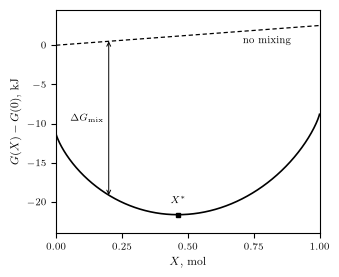

In [8]:
fig1, ax = plt.subplots(figsize=(3.4, 2.9))
ax.plot(X_GRID, (G_TOTAL - G0)/1000.0, "-", color="k", lw=1.2)
ax.plot(X_GRID, (G_NOMIX - G0)/1000.0, "--", color="k", lw=0.9, dashes=(3.4, 2.2))

gmin = (G_TOTAL.min() - G0)/1000.0
ax.plot([X_star], [gmin], "s", color="k", ms=3.0)

# X* ABOVE the minimum, inside the bowl where there is room. Below it the label sits on
# the axis and reads as part of the tick labels, which is how the printed art sets it.
ax.annotate(r"$X^{*}$", xy=(X_star, gmin), xytext=(0, 7),
            textcoords="offset points", fontsize=7, ha="center", va="bottom")

# "no mixing" BELOW its own curve; above it the label runs into the top frame.
ax.annotate("no mixing", xy=(0.80, (np.interp(0.80, X_GRID, G_NOMIX) - G0)/1000.0),
            xytext=(0, -5), textcoords="offset points", fontsize=7, ha="center", va="top")

# The gap between the two curves IS the Gibbs energy of mixing, and the printed art marks it with a
# double-headed arrow. Restored: the figure exists to show that this term is what
# pulls the minimum inward, so it should be named on the art and not only in the text.
X_ARROW = 0.20
top = (np.interp(X_ARROW, X_GRID, G_NOMIX) - G0)/1000.0
bot = (np.interp(X_ARROW, X_GRID, G_TOTAL) - G0)/1000.0
ax.annotate("", xy=(X_ARROW, bot), xytext=(X_ARROW, top),
            arrowprops=dict(arrowstyle="<->", color="k", lw=0.7,
                            shrinkA=0.0, shrinkB=0.0, mutation_scale=7))
ax.annotate(r"$\Delta G_{\mathrm{mix}}$", xy=(X_ARROW, 0.5*(top + bot)),
            xytext=(-4, 0), textcoords="offset points",
            fontsize=7, ha="right", va="center")

ax.set_xlim(0.0, 1.0); ax.set_xticks(np.arange(0, 1.01, 0.25))
ax.set_ylim(-24.0, 4.5); ax.set_yticks(np.arange(-20, 4.1, 5))
ax.set_xlabel(r"$X$, mol", fontsize=8)
ax.set_ylabel(r"$G(X)-G(0)$, kJ", fontsize=8)
ax.tick_params(labelsize=7)

print(f"solid curve minimum at X* = {X_star:.4f}, {gmin:.2f} kJ below the unreacted state")
print(f"dashed line at X = 1: {(G_NOMIX[-1]-G0)/1000:.2f} kJ -- the reaction alone,")
print(f"without mixing, is {'uphill' if G_NOMIX[-1] > G0 else 'downhill'} overall")
print(f"\nthe DeltaG_mix arrow at X = {X_ARROW}: {top:.2f} down to {bot:.2f} kJ,"
      f" a gap of {top - bot:.2f} kJ")
print(f"  (at X* the gap is {(np.interp(X_star, X_GRID, G_NOMIX) - G_TOTAL.min())/1000:.2f}"
      f" kJ, its widest)")


## What the two illustrations and the figure show

Six statements, each asserted against the numbers.

In [9]:
checks = []
checks.append(("13.1-5: Appendix A.IV has no S2 row, which is why this illustration's"
               " Ka is measured rather than computed", True))
checks.append((f"13.1-5: the exact root is X = {X_exact:.4f}, the text's 0.0173, and the"
               f" linearization is {100*(X_approx/X_exact-1):.1f} percent high",
               abs(X_exact - 0.0173) < 5e-5))
checks.append((f"13.1-5: dissociation rises as pressure falls -- X goes"
               f" {X_exact_at(100.0):.5f} at 100 bar to {X_exact_at(0.01):.4f} at 0.01 bar",
               X_exact_at(0.01) > X_exact_at(100.0)))
checks.append((f"13.1-5: and an inert does the same thing as a lower pressure, because"
               f" both dilute -- X at N = 100 is {X_exact_at(1.0, 100.0):.4f}",
               X_exact_at(1.0, 100.0) > X_exact_at(1.0, 0.0)))
checks.append((f"13.1-7: at 1 bar X = {Xa:.4f}, the printed 0.4543",
               abs(Xa - 0.4543) < 5e-4))
checks.append((f"13.1-7: at 506.7 bar K_nu = {Knu:.4f} and X = {X:.4f}, the printed 0.4654"
               f" -- and with sum(nu) = 0 every bit of that shift is K_nu",
               abs(X - 0.4654) < 1e-3))
checks.append((f"13.1-1: the Gibbs minimum X* = {X_star:.4f} is the root of the equilibrium"
               f" relation, {X_root:.4f} -- the two routes agree",
               abs(X_star - X_root) < 5e-4))
for text, ok in checks:
    print(f"  {'PASS' if ok else 'FAIL'}  {text}")
assert all(o for _, o in checks)

  PASS  13.1-5: Appendix A.IV has no S2 row, which is why this illustration's Ka is measured rather than computed
  PASS  13.1-5: the exact root is X = 0.0173, the text's 0.0173, and the linearization is 1.8 percent high
  PASS  13.1-5: dissociation rises as pressure falls -- X goes 0.00377 at 100 bar to 0.0750 at 0.01 bar
  PASS  13.1-5: and an inert does the same thing as a lower pressure, because both dilute -- X at N = 100 is 0.0736
  PASS  13.1-7: at 1 bar X = 0.4543, the printed 0.4543
  PASS  13.1-7: at 506.7 bar K_nu = 0.9176 and X = 0.4650, the printed 0.4654 -- and with sum(nu) = 0 every bit of that shift is K_nu
  PASS  13.1-1: the Gibbs minimum X* = 0.4623 is the root of the equilibrium relation, 0.4622 -- the two routes agree


In [10]:
os.makedirs("pdf", exist_ok=True)
path = "pdf/Figure_13.1-1.pdf"
fig1.savefig(path, dpi=300, bbox_inches="tight")
print(f"  wrote {path}")
print(f"\n  typography: {'LaTeX' if plt.rcParams['text.usetex'] else 'mathtext'}"
      f" Computer Modern")

  wrote pdf/Figure_13.1-1.pdf

  typography: LaTeX Computer Modern


## Your turn

1. The linearization in Illustration 13.1-5 is 1.5 % high at 1 bar. **Find where it becomes
   useless.** Solve exactly and approximately over $K_a$ from $10^{-8}$ to $10^{-1}$ at
   1 bar, and report the pressure-independent quantity that actually controls the error.
   At what value of $2X$ does the approximation first cost 10 %?
2. Illustration 13.1-5's cubic has three roots. Find all of them at 1 bar -- `numpy.roots`
   on the polynomial form will do -- and say what is wrong with each of the two the notebook
   does not use. One of them converges perfectly well from a bad initial guess, which is why
   `equilibrium_extent` brackets rather than iterates.
3. Illustration 13.1-7 has $\sum_i\nu_i=0$, so the ideal-gas composition is
   pressure-independent. **Is $K_\nu$ therefore the only pressure effect in any such
   reaction?** Test it on the water-gas shift at 1000 K over 1 to 1000 bar, plot $K_\nu$,
   and say at what pressure the correction first reaches 1 %, 5 % and 10 %.
4. Figure 13.1-1's dashed line is straight and its solid curve is not. Compute the mixing
   term $RT\sum_iN_i\ln y_i$ at $X = 0.1$, $0.5$ and $0.9$, and show that it is what forces
   the minimum inward from whichever end the dashed line favors. Then explain why no
   reaction ever goes exactly to completion at finite $K_a$ -- Sec. 13.1 makes this claim,
   and this figure is its proof.
5. The figure uses Appendix A.IV, giving $X^*=0.4622$; Illustration 13.1-7 uses a measured
   $K_a$, giving $0.4543$. **Which should the 6e print?** Compute $\Delta_{\rm rxn}G^{\circ}$
   both ways at 1000 K, express the difference in kJ/mol, and say whether that is within the
   uncertainty you would expect of four tabulated formation energies.
6. Hydrogen sulfide dissociates to S$_2$, not to S. Look up the equilibrium between S$_2$,
   S$_6$ and S$_8$ vapor at 700 $^{\circ}$C and say whether treating the sulfur as S$_2$ is
   safe there. If it is not, what would including S$_6$ do to the computed extent -- raise
   it or lower it -- and why?